# Trabajo Práctico N.º 1 — Un primer encuentro con la EPH

**Materia:** Taller de Programación  
**Estudiante:** Estefanía  
**Grupo:** 1 — *Formal wage employees*  
**Períodos analizados:** cuarto trimestre de 2024 y cuarto trimestre de 2025

El objetivo es armonizar y limpiar los microdatos individuales de la Encuesta Permanente de Hogares (EPH), describir la información disponible y comparar la formalidad laboral y los ingresos entre ambos períodos.

## Fuentes y criterio general

Se utilizan las bases individuales `usu_individual_T424.xlsx` y `usu_individual_T425.xlsx`, junto con los diseños de registro publicados por el INDEC. Para el Grupo 1, la clasificación de Maurizio y Monsalvo (2021) identifica como asalariado formal en Argentina a quien declara que su empleador realiza el descuento jubilatorio.

Las estimaciones de porcentajes poblacionales usan `PONDERA`. Los ingresos de 2024T4 se expresan a precios de 2025T4 mediante el IPC nacional nivel general.

# Parte I. Familiarización con la EPH y limpieza

## Inciso 1. Identificación de la informalidad

La informalidad puede medirse desde un enfoque legal, que observa si la relación laboral se encuentra alcanzada por la normativa laboral y la protección social. En este trabajo se estudia a los asalariados: se considera **formal** a la persona ocupada y asalariada (`ESTADO = 1` y `CAT_OCUP = 3`) que declara descuento jubilatorio (`PP07H = 1`), e **informal** a quien declara que no tiene ese descuento (`PP07H = 2`). Las personas no asalariadas quedan fuera de esta clasificación.

## Inciso 2.a. Carga, selección y armonización de variables

Antes de ejecutar la notebook, los dos archivos Excel deben estar cargados en el mismo directorio. Se seleccionan veinte variables de interés y seis variables de identificación.

In [2]:
from pathlib import Path
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

# Busca una copia válida de cada archivo, aunque Colab haya agregado (1) al nombre
def buscar_excel(patron):
    candidatos = sorted(
        Path.cwd().glob(patron),
        key=lambda archivo: archivo.stat().st_mtime,
        reverse=True
    )

    validos = [archivo for archivo in candidatos if zipfile.is_zipfile(archivo)]

    if not validos:
        encontrados = [archivo.name for archivo in candidatos]
        raise FileNotFoundError(
            f"No se encontró un Excel válido para {patron}. "
            f"Archivos encontrados: {encontrados}"
        )

    return validos[0]

ruta_2024 = buscar_excel("usu_individual_T424.xlsx")
ruta_2025 = buscar_excel("usu_individual_T425.xlsx")

print("Archivo 2024 utilizado:", ruta_2024.name)
print("Archivo 2025 utilizado:", ruta_2025.name)


Archivo 2024 utilizado: usu_individual_T424.xlsx
Archivo 2025 utilizado: usu_individual_T425.xlsx


In [3]:
variables_id = [
    "CODUSU", "ANO4", "TRIMESTRE", "NRO_HOGAR",
    "COMPONENTE", "PONDERA"
]

variables_interes = [
    "CH04", "CH06", "CH07", "CH08", "NIVEL_ED",
    "ESTADO", "CAT_OCUP", "EMPLEO", "SECTOR",
    "PP04C", "PP04D_COD", "P21", "P47T",
    "REGION", "AGLOMERADO", "CH03", "PP04A",
    "PP04B_COD", "PP07H", "PP07I"
]

variables_seleccionadas = variables_id + variables_interes

columnas_2024 = pd.read_excel(ruta_2024, nrows=0).columns.str.strip().str.upper()
columnas_2025 = pd.read_excel(ruta_2025, nrows=0).columns.str.strip().str.upper()

faltan_2024 = [v for v in variables_seleccionadas if v not in columnas_2024]
faltan_2025 = [v for v in variables_seleccionadas if v not in columnas_2025]

print("Variables faltantes en 2024:", faltan_2024)
print("Variables faltantes en 2025:", faltan_2025)
print("Variables de interés:", len(variables_interes))

Variables faltantes en 2024: []
Variables faltantes en 2025: []
Variables de interés: 20


In [4]:
df_2024 = pd.read_excel(
    ruta_2024,
    usecols=variables_seleccionadas,
    dtype={"CODUSU": "string", "PP04D_COD": "string"}
)

df_2025 = pd.read_excel(
    ruta_2025,
    usecols=variables_seleccionadas,
    dtype={"CODUSU": "string", "PP04D_COD": "string"}
)

df_2024.columns = df_2024.columns.str.strip().str.upper()
df_2025.columns = df_2025.columns.str.strip().str.upper()

variables_texto = ["CODUSU", "PP04D_COD"]
variables_ingreso = ["P21", "P47T"]
variables_enteras = [
    v for v in variables_seleccionadas
    if v not in variables_texto + variables_ingreso
]

for datos in [df_2024, df_2025]:
    for v in variables_texto:
        datos[v] = datos[v].astype("string").str.strip()
    for v in variables_ingreso:
        datos[v] = pd.to_numeric(datos[v], errors="coerce").astype("Float64")
    for v in variables_enteras:
        datos[v] = pd.to_numeric(datos[v], errors="coerce").astype("Int64")

df_2024["PERIODO"] = "2024T4"
df_2025["PERIODO"] = "2025T4"

auditoria_tipos = pd.DataFrame({
    "variable": variables_seleccionadas,
    "tipo_2024": [str(df_2024[v].dtype) for v in variables_seleccionadas],
    "tipo_2025": [str(df_2025[v].dtype) for v in variables_seleccionadas]
})
auditoria_tipos["coinciden"] = (
    auditoria_tipos["tipo_2024"] == auditoria_tipos["tipo_2025"]
)

print("Dimensión 2024:", df_2024.shape)
print("Dimensión 2025:", df_2025.shape)
print("Tipos diferentes:", (~auditoria_tipos["coinciden"]).sum())
display(auditoria_tipos)

Dimensión 2024: (46860, 27)
Dimensión 2025: (43703, 27)
Tipos diferentes: 0


,variable,tipo_2024,tipo_2025,coinciden
0,CODUSU,string,string,True
1,ANO4,Int64,Int64,True
2,TRIMESTRE,Int64,Int64,True
3,NRO_HOGAR,Int64,Int64,True
4,COMPONENTE,Int64,Int64,True
5,PONDERA,Int64,Int64,True
6,CH04,Int64,Int64,True
7,CH06,Int64,Int64,True
8,CH07,Int64,Int64,True
9,CH08,Int64,Int64,True


## Inciso 2.b. Limpieza de datos

Se reemplazan por valores faltantes los códigos de no respuesta indicados en los diseños de registro. En los ingresos, -9 representa falta de respuesta. También se tratan como faltantes las categorías fuera del dominio válido y los códigos especiales de actividad y ocupación. En ch06, el valor -1 se recodifica como 0, dado que corresponde a personas con menos de un año de edad.

In [5]:
base_2024 = df_2024.copy()
base_2025 = df_2025.copy()

for datos in [base_2024, base_2025]:

    # Ingresos: -9 indica no respuesta
    datos[["P21", "P47T"]] = datos[["P21", "P47T"]].mask(
        datos[["P21", "P47T"]] < 0
    )

    # Edad y variables sociodemográficas
    datos["CH06"] = datos["CH06"].replace(-1, 0)
    datos["CH07"] = datos["CH07"].where(datos["CH07"].isin([1, 2, 3, 4, 5]))
    datos["CH08"] = datos["CH08"].replace(9, pd.NA)
    datos["NIVEL_ED"] = datos["NIVEL_ED"].replace(9, pd.NA)

    # Variables laborales
    datos["CAT_OCUP"] = datos["CAT_OCUP"].replace([0, 9], pd.NA)
    datos["EMPLEO"] = datos["EMPLEO"].replace(9, pd.NA)
    datos["SECTOR"] = datos["SECTOR"].replace(9, pd.NA)

    datos["PP04A"] = datos["PP04A"].where(datos["PP04A"].isin([1, 2, 3]))
    datos["PP04C"] = datos["PP04C"].where(datos["PP04C"].between(1, 12))
    datos["PP04B_COD"] = datos["PP04B_COD"].replace([0, 9999], pd.NA)

    datos["PP04D_COD"] = datos["PP04D_COD"].replace(
        ["0", "00000", "99997", "99998", "99999"],
        pd.NA
    )

    datos["PP07H"] = datos["PP07H"].where(datos["PP07H"].isin([1, 2]))
    datos["PP07I"] = datos["PP07I"].where(datos["PP07I"].isin([1, 2]))

control_limpieza = pd.DataFrame({
    "2024": [
        (base_2024["P21"] < 0).sum(),
        (base_2024["P47T"] < 0).sum(),
        (~base_2024["CH07"].dropna().isin([1, 2, 3, 4, 5])).sum()
    ],
    "2025": [
        (base_2025["P21"] < 0).sum(),
        (base_2025["P47T"] < 0).sum(),
        (~base_2025["CH07"].dropna().isin([1, 2, 3, 4, 5])).sum()
    ]
}, index=["P21 negativos", "P47T negativos", "CH07 inválidos"])

display(control_limpieza)

,2024,2025
P21 negativos,0,0
P47T negativos,0,0
CH07 inválidos,0,0


## Incisos 3 y 4. Condición de actividad y selección de ocupados

Se unen ambos años y se separan las observaciones según `ESTADO`. La base `norespondieron` contiene los casos con entrevista individual no realizada (`ESTADO = 0`). La base `respondieron` conserva el resto y `ocupados` incluye únicamente a quienes tienen `ESTADO = 1`.

In [6]:
base = pd.concat([base_2024, base_2025], ignore_index=True)

norespondieron = base[base["ESTADO"] == 0].copy()
respondieron = base[base["ESTADO"] != 0].copy()
ocupados = respondieron[respondieron["ESTADO"] == 1].copy()

resumen_bases = pd.DataFrame({
    "No respondieron": norespondieron.groupby("PERIODO").size(),
    "Respondieron": respondieron.groupby("PERIODO").size(),
    "Ocupados": ocupados.groupby("PERIODO").size()
})
resumen_bases.loc["Total"] = resumen_bases.sum()

display(resumen_bases)
print("Control del total:", len(respondieron) + len(norespondieron), "=", len(base))

,No respondieron,Respondieron,Ocupados
PERIODO,,,
2024T4,56,46804,21132
2025T4,65,43638,19698
Total,121,90442,40830


Control del total: 90563 = 90563


## Inciso 5. Variables binarias

Se construyen indicadores simples para facilitar las comparaciones posteriores. Las etiquetas se escriben en castellano para que las tablas y los gráficos sean interpretables.

In [7]:
ocupados["mujer"] = ocupados["CH04"].map({1: 0, 2: 1}).astype("Int64")
ocupados["sexo"] = ocupados["CH04"].map({1: "Varones", 2: "Mujeres"})

ocupados["asalariado"] = ocupados["CAT_OCUP"].map({
    1: 0, 2: 0, 3: 1, 4: 0
}).astype("Int64")

ocupados["secundario_completo_o_mas"] = ocupados["NIVEL_ED"].map({
    1: 0, 2: 0, 3: 0, 4: 1, 5: 1, 6: 1, 7: 0
}).astype("Int64")

ocupados["con_cobertura_medica"] = ocupados["CH08"].map({
    1: 1, 2: 1, 3: 1, 4: 0,
    12: 1, 13: 1, 23: 1, 123: 1
}).astype("Int64")

ocupados["empresa_hasta_5"] = pd.Series(pd.NA, index=ocupados.index, dtype="Int64")
ocupados.loc[ocupados["PP04C"].between(1, 5), "empresa_hasta_5"] = 1
ocupados.loc[ocupados["PP04C"].between(6, 12), "empresa_hasta_5"] = 0

ocupados["formal_asalariado"] = pd.Series(
    pd.NA, index=ocupados.index, dtype="Int64"
)
ocupados.loc[
    (ocupados["CAT_OCUP"] == 3) & (ocupados["PP07H"] == 1),
    "formal_asalariado"
] = 1
ocupados.loc[
    (ocupados["CAT_OCUP"] == 3) & (ocupados["PP07H"] == 2),
    "formal_asalariado"
] = 0

ocupados["condicion_laboral"] = ocupados["formal_asalariado"].map({
    1: "Formal", 0: "Informal"
})

tabla_casos = pd.crosstab(ocupados["PERIODO"], ocupados["condicion_laboral"])
display(tabla_casos)

condicion_laboral,Formal,Informal
PERIODO,,
2024T4,9727,5565
2025T4,8815,5128


## Inciso 6. Actualización de los ingresos

Se construye un índice encadenado a partir de las variaciones mensuales del IPC nacional. El factor de actualización resulta del cociente entre el IPC promedio de octubre-diciembre de 2025 y el promedio del mismo trimestre de 2024.

In [8]:
inflacion_2024 = [
    20.6, 13.2, 11.0, 8.8, 4.2, 4.6,
    4.0, 4.2, 3.5, 2.7, 2.4, 2.7
]

inflacion_2025 = [
    2.2, 2.4, 3.7, 2.8, 1.5, 1.6,
    1.9, 1.9, 2.1, 2.3, 2.5, 2.8
]

ipc = pd.DataFrame({
    "año": [2024] * 12 + [2025] * 12,
    "mes": list(range(1, 13)) * 2,
    "variacion_mensual": inflacion_2024 + inflacion_2025
})

indice = 100
serie_indice = []

for variacion in ipc["variacion_mensual"]:
    indice = indice * (1 + variacion / 100)
    serie_indice.append(indice)

ipc["indice_ipc"] = serie_indice

ipc_trimestre = ipc[ipc["mes"].isin([10, 11, 12])]
ipc_promedio = ipc_trimestre.groupby("año")["indice_ipc"].mean()
factor_ipc = ipc_promedio.loc[2025] / ipc_promedio.loc[2024]

print("IPC promedio 2024T4:", round(ipc_promedio.loc[2024], 2))
print("IPC promedio 2025T4:", round(ipc_promedio.loc[2025], 2))
print("Factor de actualización:", round(factor_ipc, 4))

IPC promedio 2024T4: 212.21
IPC promedio 2025T4: 278.74
Factor de actualización: 1.3135


In [9]:
for datos in [respondieron, ocupados]:
    datos["P21_nominal"] = datos["P21"].copy()
    datos["P47T_nominal"] = datos["P47T"].copy()

    es_2024 = datos["PERIODO"] == "2024T4"
    datos.loc[es_2024, "P21"] = datos.loc[es_2024, "P21"] * factor_ipc
    datos.loc[es_2024, "P47T"] = datos.loc[es_2024, "P47T"] * factor_ipc

medianas_ingreso = ocupados.groupby("PERIODO")[["P21", "P47T"]].median().round(0)
display(medianas_ingreso)

,P21,P47T
PERIODO,,
2024T4,656755.0,774971.0
2025T4,800000.0,800000.0


## Inciso 7. Valores faltantes

El heatmap compara el porcentaje de `NaN` de las veinte variables de interés en `respondieron` y `ocupados`. El número de observaciones de cada base se informa en el encabezado.

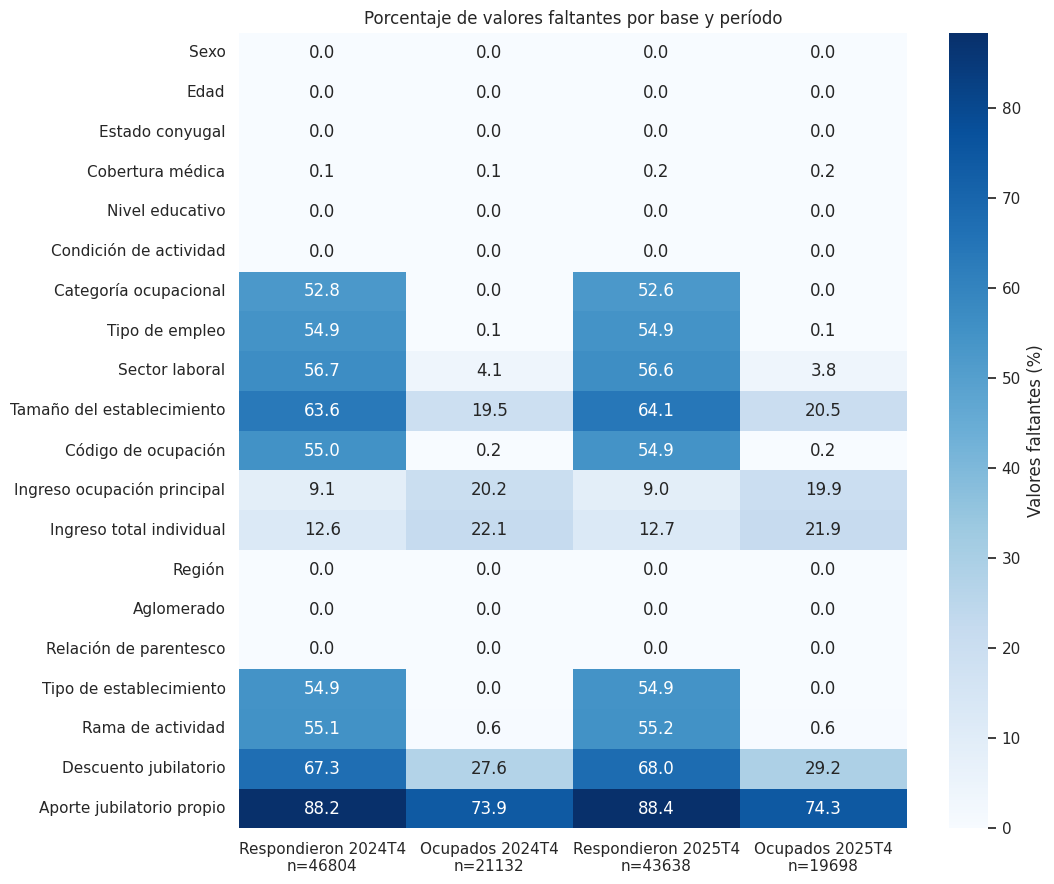

In [10]:
etiquetas_variables = {
    "CH04": "Sexo",
    "CH06": "Edad",
    "CH07": "Estado conyugal",
    "CH08": "Cobertura médica",
    "NIVEL_ED": "Nivel educativo",
    "ESTADO": "Condición de actividad",
    "CAT_OCUP": "Categoría ocupacional",
    "EMPLEO": "Tipo de empleo",
    "SECTOR": "Sector laboral",
    "PP04C": "Tamaño del establecimiento",
    "PP04D_COD": "Código de ocupación",
    "P21": "Ingreso ocupación principal",
    "P47T": "Ingreso total individual",
    "REGION": "Región",
    "AGLOMERADO": "Aglomerado",
    "CH03": "Relación de parentesco",
    "PP04A": "Tipo de establecimiento",
    "PP04B_COD": "Rama de actividad",
    "PP07H": "Descuento jubilatorio",
    "PP07I": "Aporte jubilatorio propio"
}

respondieron_2024 = respondieron[respondieron["PERIODO"] == "2024T4"]
respondieron_2025 = respondieron[respondieron["PERIODO"] == "2025T4"]
ocupados_2024 = ocupados[ocupados["PERIODO"] == "2024T4"]
ocupados_2025 = ocupados[ocupados["PERIODO"] == "2025T4"]

faltantes = pd.DataFrame({
    f"Respondieron 2024T4\nn={len(respondieron_2024)}":
        respondieron_2024[variables_interes].isna().mean() * 100,
    f"Ocupados 2024T4\nn={len(ocupados_2024)}":
        ocupados_2024[variables_interes].isna().mean() * 100,
    f"Respondieron 2025T4\nn={len(respondieron_2025)}":
        respondieron_2025[variables_interes].isna().mean() * 100,
    f"Ocupados 2025T4\nn={len(ocupados_2025)}":
        ocupados_2025[variables_interes].isna().mean() * 100
}).round(1)

faltantes = faltantes.rename(index=etiquetas_variables)

plt.figure(figsize=(11, 9))
sns.heatmap(
    faltantes,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "Valores faltantes (%)"}
)
plt.title("Porcentaje de valores faltantes por base y período")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.savefig("heatmap_valores_faltantes.png", dpi=300, bbox_inches="tight")
plt.show()

**Comentario.** Las variables sociodemográficas presentan muy pocos faltantes en ambos años. Las variables asociadas al puesto de trabajo muestran una proporción mayor en respondieron, porque no se preguntan a toda la población. Al restringir la base a ocupados disminuyen los faltantes de EMPLEO, SECTOR,PP04A y los códigos de actividad y ocupación. En cambio, P21 y P47T mantienen una no respuesta cercana al 20 % entre ocupados. El patrón es muy similar en 2024T4 y 2025T4.

# Parte II. Primer análisis exploratorio

## Inciso 8. Matrices de correlación

Se calculan correlaciones de Pearson en la base respondieron, dado que ESTADO conserva variación. Como varias variables son categóricas codificadas con números, sus coeficientes se interpretan solamente como una descripción de asociación y no como relaciones causales.

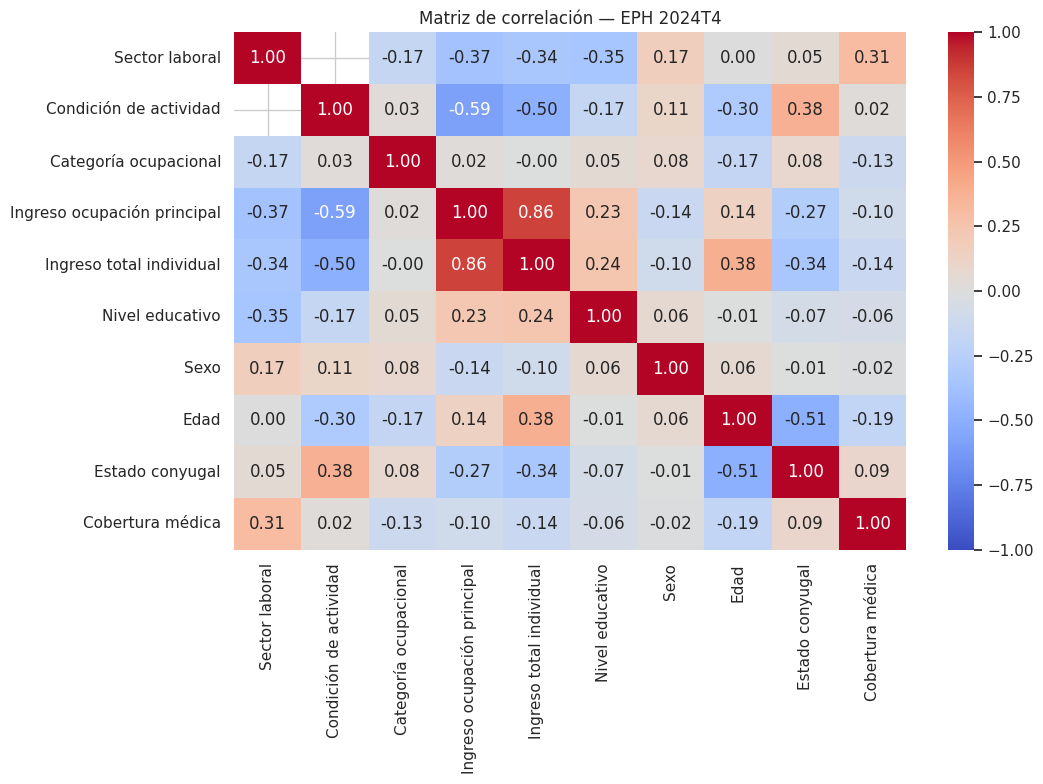

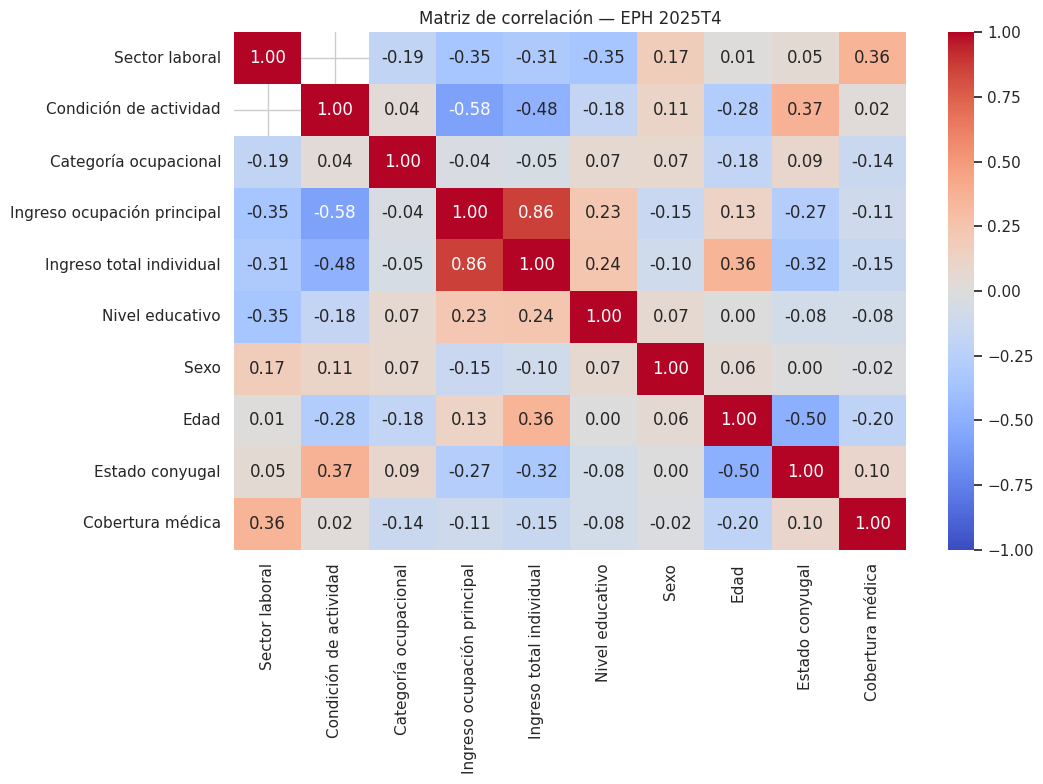

In [11]:
variables_correlacion = [
    "SECTOR", "ESTADO", "CAT_OCUP", "P21", "P47T",
    "NIVEL_ED", "CH04", "CH06", "CH07", "CH08"
]

etiquetas_correlacion = {
    "SECTOR": "Sector laboral",
    "ESTADO": "Condición de actividad",
    "CAT_OCUP": "Categoría ocupacional",
    "P21": "Ingreso ocupación principal",
    "P47T": "Ingreso total individual",
    "NIVEL_ED": "Nivel educativo",
    "CH04": "Sexo",
    "CH06": "Edad",
    "CH07": "Estado conyugal",
    "CH08": "Cobertura médica"
}

matrices = {}

for periodo in ["2024T4", "2025T4"]:
    datos_corr = respondieron[
        respondieron["PERIODO"] == periodo
    ][variables_correlacion].astype(float)

    matriz = datos_corr.corr()
    matrices[periodo] = matriz

    matriz_grafico = matriz.rename(
        index=etiquetas_correlacion,
        columns=etiquetas_correlacion
    )

    plt.figure(figsize=(11, 8))
    sns.heatmap(
        matriz_grafico,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1
    )
    plt.title(f"Matriz de correlación — EPH {periodo}")
    plt.tight_layout()
    plt.savefig(f"matriz_correlacion_{periodo}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [12]:
diferencia = (matrices["2025T4"] - matrices["2024T4"]).abs()

for v in variables_correlacion:
    diferencia.loc[v, v] = np.nan

cambios = diferencia.stack().reset_index()
cambios.columns = ["variable_1", "variable_2", "cambio_absoluto"]

cambios["par"] = cambios.apply(
    lambda fila: " - ".join(sorted([fila["variable_1"], fila["variable_2"]])),
    axis=1
)

cambios = (
    cambios.drop_duplicates("par")
    .sort_values("cambio_absoluto", ascending=False)
)

display(cambios[["variable_1", "variable_2", "cambio_absoluto"]].head(5).round(3))

,variable_1,variable_2,cambio_absoluto
18,CAT_OCUP,P21,0.055
19,CAT_OCUP,P47T,0.048
7,SECTOR,CH08,0.048
40,P47T,CH06,0.029
1,SECTOR,P21,0.028


**Comentario.** La correlación más alta en ambos años se observa entre SECTOR y ocupacion, lo que resulta esperable porque el ingreso de la ocupación principal integra el ingreso total individual. También se observan asociaciones entre edad e ingreso total. En general, las diferencias entre las matrices son pequeñas: el mayor cambio absoluto es inferior a 0,05. Por lo tanto, no se identifican modificaciones importantes en la estructura de correlaciones entre 2024T4 y 2025T4.

## Inciso 9. Estadísticas descriptivas

La tabla incluye cantidad de observaciones válidas, promedio, desvío estándar, mínimo, percentiles 1, 25, 50, 75 y 99, y máximo. En las variables categóricas, los promedios describen códigos y no poseen una interpretación económica directa.

In [13]:
def tabla_descriptiva(datos):
    tabla = datos[variables_interes].copy()
    tabla["PP04D_COD"] = pd.to_numeric(tabla["PP04D_COD"], errors="coerce")

    resultado = tabla.describe(
        percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
    ).T

    resultado = resultado[
        ["count", "mean", "std", "min", "1%", "25%", "50%", "75%", "99%", "max"]
    ]

    resultado.columns = [
        "n", "promedio", "desvío", "mínimo",
        "p1", "p25", "p50", "p75", "p99", "máximo"
    ]

    return resultado.rename(index=etiquetas_variables).round(2)

descriptivos_2024 = tabla_descriptiva(respondieron_2024)
descriptivos_2025 = tabla_descriptiva(respondieron_2025)

print("Estadísticas descriptivas — 2024T4")
display(descriptivos_2024)

print("Estadísticas descriptivas — 2025T4")
display(descriptivos_2025)

Estadísticas descriptivas — 2024T4


,n,promedio,desvío,mínimo,p1,p25,p50,p75,p99,máximo
Sexo,46804.0,1.52,0.5,1.0,1.0,1.0,2.0,2.0,2.0,2.0
Edad,46804.0,36.77,22.18,0.0,1.0,18.0,35.0,54.0,85.0,103.0
Estado conyugal,46804.0,3.52,1.65,1.0,1.0,2.0,5.0,5.0,5.0,5.0
Cobertura médica,46762.0,2.13,1.86,1.0,1.0,1.0,1.0,4.0,12.0,123.0
Nivel educativo,46804.0,3.78,1.76,1.0,1.0,3.0,4.0,5.0,7.0,7.0
Condición de actividad,46804.0,2.18,1.13,1.0,1.0,1.0,3.0,3.0,4.0,4.0
Categoría ocupacional,22076.0,2.7,0.54,1.0,1.0,2.0,3.0,3.0,3.0,4.0
Tipo de empleo,21116.0,1.43,0.5,1.0,1.0,1.0,1.0,2.0,2.0,2.0
Sector laboral,20275.0,1.38,0.61,1.0,1.0,1.0,1.0,2.0,3.0,3.0
Tamaño del establecimiento,17014.0,5.41,3.65,1.0,1.0,2.0,6.0,8.0,12.0,12.0


Estadísticas descriptivas — 2025T4


,n,promedio,desvío,mínimo,p1,p25,p50,p75,p99,máximo
Sexo,43638.0,1.53,0.5,1.0,1.0,1.0,2.0,2.0,2.0,2.0
Edad,43638.0,37.59,22.32,0.0,1.0,19.0,36.0,55.0,86.0,101.0
Estado conyugal,43637.0,3.51,1.65,1.0,1.0,2.0,5.0,5.0,5.0,5.0
Cobertura médica,43535.0,2.14,1.74,1.0,1.0,1.0,1.0,4.0,12.0,23.0
Nivel educativo,43638.0,3.75,1.74,1.0,1.0,3.0,4.0,5.0,7.0,7.0
Condición de actividad,43638.0,2.17,1.12,1.0,1.0,1.0,3.0,3.0,4.0,4.0
Categoría ocupacional,20673.0,2.68,0.54,1.0,1.0,2.0,3.0,3.0,3.0,4.0
Tipo de empleo,19688.0,1.44,0.5,1.0,1.0,1.0,1.0,2.0,2.0,2.0
Sector laboral,18948.0,1.39,0.62,1.0,1.0,1.0,1.0,2.0,3.0,3.0
Tamaño del establecimiento,15662.0,5.22,3.66,1.0,1.0,1.0,5.0,8.0,12.0,12.0


**Comentario.** La edad media aumenta levemente entre ambos períodos. Los ingresos presentan una dispersión elevada y una marcada distancia entre la mediana y los percentiles superiores, lo que evidencia una distribución asimétrica. En las variables laborales, el número de observaciones es menor porque solo se completan para las personas a quienes corresponde cada bloque del cuestionario.

# Parte III. Informalidad laboral

## Inciso 10. Asalariados formales e informales

La tabla utiliza pondera para estimar la composición poblacional. Se presentan los porcentajes para el total de asalariados clasificados y para mujeres y varones por separado.

In [14]:
asalariados = ocupados[ocupados["formal_asalariado"].notna()].copy()

filas = []

for periodo in ["2024T4", "2025T4"]:
    datos_periodo = asalariados[asalariados["PERIODO"] == periodo]

    grupos = {
        "Total": datos_periodo,
        "Mujeres": datos_periodo[datos_periodo["CH04"] == 2],
        "Varones": datos_periodo[datos_periodo["CH04"] == 1]
    }

    for grupo, datos_grupo in grupos.items():
        total_ponderado = datos_grupo["PONDERA"].sum()

        formal = (
            datos_grupo.loc[
                datos_grupo["formal_asalariado"] == 1, "PONDERA"
            ].sum() / total_ponderado * 100
        )

        informal = (
            datos_grupo.loc[
                datos_grupo["formal_asalariado"] == 0, "PONDERA"
            ].sum() / total_ponderado * 100
        )

        filas.append([periodo, grupo, formal, informal])

tabla_formalidad = pd.DataFrame(
    filas,
    columns=["Período", "Grupo", "Formal (%)", "Informal (%)"]
)

tabla_formalidad[["Formal (%)", "Informal (%)"]] = (
    tabla_formalidad[["Formal (%)", "Informal (%)"]].round(1)
)

display(tabla_formalidad)

,Período,Grupo,Formal (%),Informal (%)
0,2024T4,Total,63.9,36.1
1,2024T4,Mujeres,61.6,38.4
2,2024T4,Varones,65.8,34.2
3,2025T4,Total,63.7,36.3
4,2025T4,Mujeres,61.6,38.4
5,2025T4,Varones,65.5,34.5


**Comentario.** La proporción estimada de asalariados formales se mantiene prácticamente estable: 63,9 % en 2024T4 y 63,7 % en 2025T4. En ambos años la formalidad es menor entre las mujeres (61,6 %) que entre los varones (alrededor de 65,5 %). La diferencia por sexo persiste, aunque no se observa un cambio interanual relevante en la composición general.

## Inciso 11. Distribución de ingresos

Se presentan histogramas y estimaciones kernel para P21 y P47T, distinguiendo asalariados formales e informales. Para que los valores extremos no oculten la forma central de la distribución, el eje horizontal se limita al percentil 99 de cada variable y período. Los gráficos utilizan `PONDERA`.

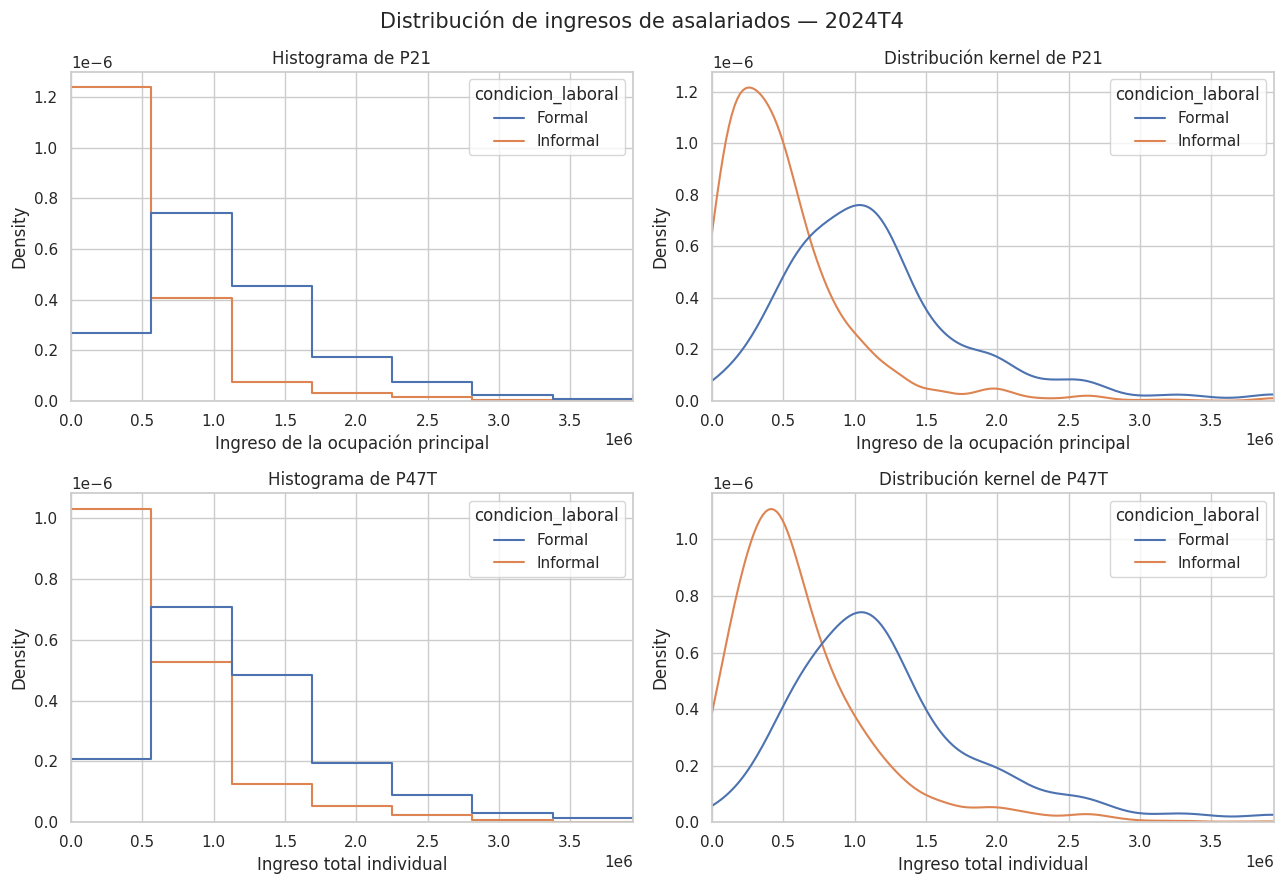

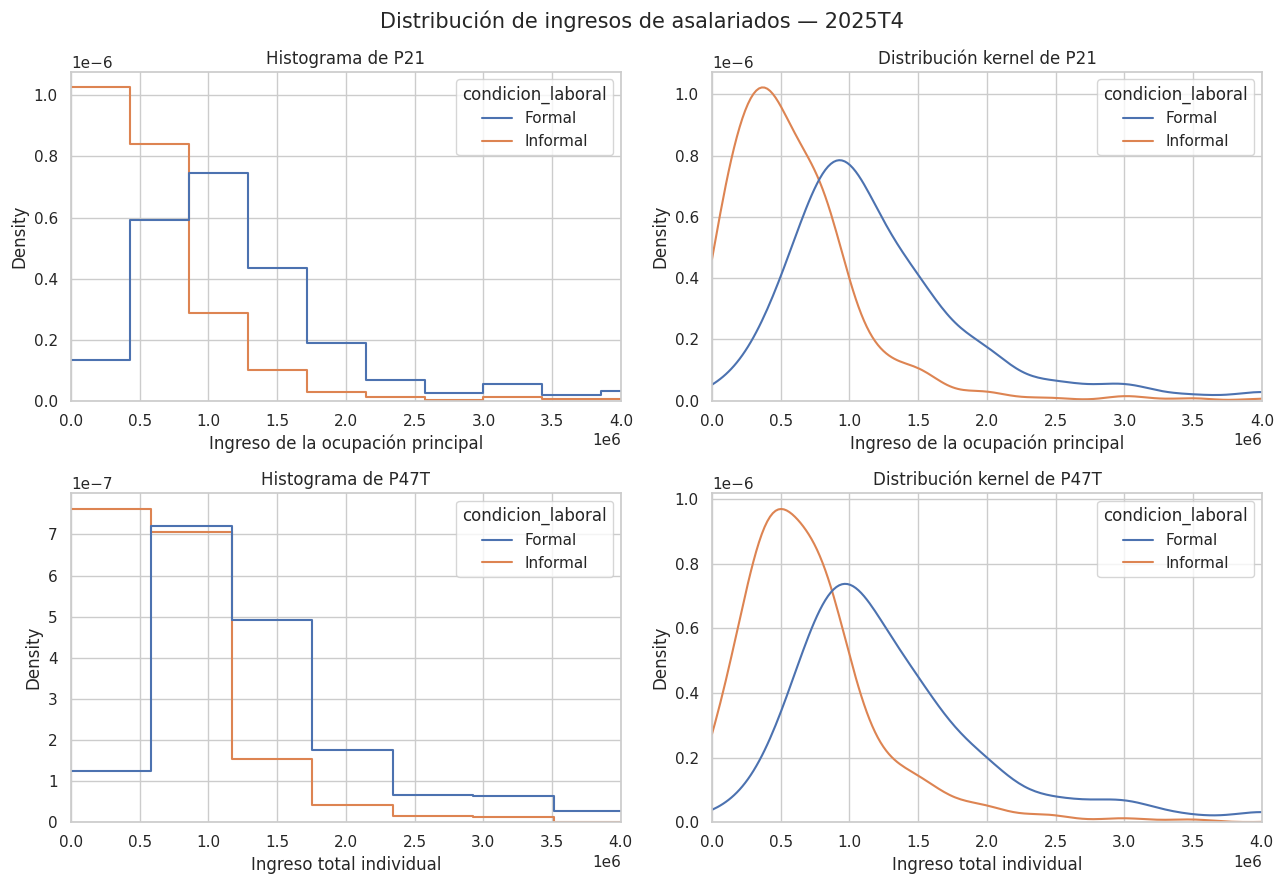

In [15]:
for periodo in ["2024T4", "2025T4"]:

    datos_grafico = asalariados[
        asalariados["PERIODO"] == periodo
    ].copy()

    limite_p21 = datos_grafico["P21"].quantile(0.99)
    limite_p47t = datos_grafico["P47T"].quantile(0.99)

    fig, ejes = plt.subplots(2, 2, figsize=(13, 9))

    sns.histplot(
        data=datos_grafico,
        x="P21",
        hue="condicion_laboral",
        weights="PONDERA",
        stat="density",
        common_norm=False,
        bins=35,
        element="step",
        fill=False,
        ax=ejes[0, 0]
    )
    ejes[0, 0].set_xlim(0, limite_p21)
    ejes[0, 0].set_title("Histograma de P21")
    ejes[0, 0].set_xlabel("Ingreso de la ocupación principal")

    sns.kdeplot(
        data=datos_grafico,
        x="P21",
        hue="condicion_laboral",
        weights="PONDERA",
        common_norm=False,
        cut=0,
        clip=(0, limite_p21),
        ax=ejes[0, 1]
    )
    ejes[0, 1].set_xlim(0, limite_p21)
    ejes[0, 1].set_title("Distribución kernel de P21")
    ejes[0, 1].set_xlabel("Ingreso de la ocupación principal")

    sns.histplot(
        data=datos_grafico,
        x="P47T",
        hue="condicion_laboral",
        weights="PONDERA",
        stat="density",
        common_norm=False,
        bins=35,
        element="step",
        fill=False,
        ax=ejes[1, 0]
    )
    ejes[1, 0].set_xlim(0, limite_p47t)
    ejes[1, 0].set_title("Histograma de P47T")
    ejes[1, 0].set_xlabel("Ingreso total individual")

    sns.kdeplot(
        data=datos_grafico,
        x="P47T",
        hue="condicion_laboral",
        weights="PONDERA",
        common_norm=False,
        cut=0,
        clip=(0, limite_p47t),
        ax=ejes[1, 1]
    )
    ejes[1, 1].set_xlim(0, limite_p47t)
    ejes[1, 1].set_title("Distribución kernel de P47T")
    ejes[1, 1].set_xlabel("Ingreso total individual")

    fig.suptitle(
        f"Distribución de ingresos de asalariados — {periodo}",
        fontsize=15
    )
    plt.tight_layout()
    plt.savefig(
        f"distribucion_ingresos_{periodo}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

**Comentario.** En los dos períodos, las distribuciones de los asalariados formales se encuentran desplazadas hacia ingresos más altos, mientras que la mayor parte de los informales se concentra en niveles inferiores. P21 refleja solamente el ingreso habitual de la ocupación principal; P47T incorpora otros ingresos laborales y no laborales. Ambas variables presentan no respuesta y valores extremos. Además, el recorte visual en el percentil 99 mejora la lectura, pero no elimina esas observaciones de la base.

# Parte IV. Uso de herramientas de IA y reflexión final

La IA fue útil para ordenar la secuencia del trabajo, revisar fragmentos de código y traducir la consigna en tareas más pequeñas. Resultó menos efectiva cuando fue necesario interpretar códigos específicos del diccionario de la EPH, porque algunas sugerencias debieron contrastarse con la documentación y corregirse. También ayudó a revisar los gráficos y la presentación de resultados. El uso fue de apoyo: cada bloque fue ejecutado, revisado y ajustado a partir de las salidas obtenidas.

**Modelo utilizado:** Gemini Integrado 2.5
**Tiempo total aproximado dedicado:** Aproximadamente 10 - 12 hs

# Referencias

- INDEC (2025). *Encuesta Permanente de Hogares. Diseño de registros y estructura para las bases preliminares Hogar y Personas. Cuarto trimestre de 2024*.
- INDEC (2026). *Encuesta Permanente de Hogares. Diseño de registros y estructura para las bases preliminares Hogar y Personas. Cuarto trimestre de 2025*.
- INDEC. *Índice de precios al consumidor*. Informes técnicos correspondientes a 2024 y 2025.
- Maurizio, R. y Monsalvo, A. P. (2021). *Informality, labour transitions, and the livelihoods of workers in Latin America*. UNU-WIDER Working Paper 2021/19.
- Schwabish, J. A. (2014). “An Economist's Guide to Visualizing Data”. *Journal of Economic Perspectives*, 28(1), 209–234.